# 🍇 ModelVinya · Etiquetatge automàtic amb SAM 3

Aquest notebook fa servir **SAM 3** (Meta) per segmentar automàticament les baies d'un racim i genera un **projecte `.json` de ModelVinya** (cercles + diàmetres equivalents) que pots obrir directament a l'anotador per **revisar i corregir**.

## Abans de començar
1. **Runtime amb GPU:** menú *Entorn d'execució → Canviar el tipus d'entorn → GPU*.
2. **Accés als checkpoints (gated):** demana accés a https://huggingface.co/facebook/sam3 i crea un token a https://huggingface.co/settings/tokens
3. Executa les cel·les **en ordre** (de dalt a baix).

> El prompt de text per defecte és `berry`. En racims molt densos SAM 3 pot segmentar grups; ajusta el `PROMPT` i els llindars d'àrea més avall, i acaba de polir a l'anotador. SAM 3 no compta baies amagades: això ho corregeix després el model d'oclusió (fase 2).

In [ ]:
# 1) Instal·lar SAM 3
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip -q install -e .
!pip -q install huggingface_hub pillow numpy

In [ ]:
# 2) Accés als checkpoints (gated). Enganxa el teu token de Hugging Face quan ho demani.
from huggingface_hub import login
login()   # alternativa: !hf auth login

In [ ]:
# 3) Carregar el model SAM 3
import glob
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

# El install editable (-e) no localitza el tokenizer BPE -> el passem explícitament
_bpe = glob.glob('/content/sam3/**/bpe_simple_vocab_16e6.txt.gz', recursive=True)
bpe_path = _bpe[0] if _bpe else None
print('Tokenizer BPE:', bpe_path)

model = build_sam3_image_model(bpe_path=bpe_path)
processor = Sam3Processor(model)
print('SAM 3 carregat ✔')

In [ ]:
# 4) Paràmetres i pujada d'imatges
PROMPT        = 'berry'    # concepte a segmentar (prova 'grape', 'round green berry'...)
SCORE_MIN     = 0.5        # confiança mínima per acceptar una detecció
AREA_MIN_FRAC = 0.00002    # àrea mínima de baia respecte la imatge (descarta soroll)
AREA_MAX_FRAC = 0.05       # àrea màxima (descarta el racim sencer / el fons)

from google.colab import files
uploaded = files.upload()           # selecciona una o més fotos de racims
image_paths = list(uploaded.keys())
print('Imatges:', image_paths)

In [ ]:
PROMPT = 'grape'
SCORE_MIN = 0.35                       # ens quedem amb els candidats prou segurs
processor.set_confidence_threshold(0.05)   # deixa passar candidats; filtrem nosaltres
print('Prompt =', PROMPT, '| SCORE_MIN =', SCORE_MIN)

In [ ]:
# 5) Inferència SAM 3  ->  cercles  ->  projecte ModelVinya (.json)
import numpy as np, base64, json, mimetypes, torch
from datetime import datetime, timezone
from PIL import Image

def to_np(x):
    """Tensor de PyTorch (GPU/bfloat16) o array -> numpy float32 a CPU."""
    if hasattr(x, "detach"):
        x = x.detach().cpu().float()
    return np.asarray(x)

def to_binary(mask):
    arr = np.squeeze(to_np(mask))
    if arr.dtype == bool:
        return arr
    return arr > 0.5 if arr.max() <= 1.0 else arr > 0

def mask_to_circle(binary):
    ys, xs = np.nonzero(binary)
    if len(xs) == 0:
        return None
    area = float(len(xs))
    return {"cx": round(float(xs.mean()), 2),
            "cy": round(float(ys.mean()), 2),
            "r":  round(float(np.sqrt(area / np.pi)), 2),
            "area_px": area}

def data_url(path):
    mime = mimetypes.guess_type(path)[0] or 'image/jpeg'
    with open(path, 'rb') as f:
        return f"data:{mime};base64," + base64.b64encode(f.read()).decode('ascii')

EMPTY_FICHA  = {"id_racimo": "", "fecha": "", "variedad": "", "fase_fenologica": "",
                "tratamiento": "", "vigor": "", "orientacion": "", "sistema_conduccion": ""}
EMPTY_VERDAD = {"N_total_real": "", "Diam_real_mm": "", "Peso_baya_real_g": "", "Peso_racimo_real_g": ""}

images_out = []
for path in image_paths:
    image = Image.open(path).convert('RGB')
    W, H = image.size
    with torch.autocast('cuda', dtype=torch.bfloat16):     # <-- arregla el dtype mismatch
        state  = processor.set_image(image)
        output = processor.set_text_prompt(state=state, prompt=PROMPT)

    masks  = to_np(output["masks"])
    scores = to_np(output["scores"]).reshape(-1)
    print(f"{path}: SAM 3 ha retornat {len(masks)} màscares")

    amin, amax = AREA_MIN_FRAC * W * H, AREA_MAX_FRAC * W * H
    bayas = []
    for i in range(len(masks)):
        if i < len(scores) and scores[i] < SCORE_MIN:
            continue
        c = mask_to_circle(to_binary(masks[i]))
        if c is None or c["area_px"] < amin or c["area_px"] > amax:
            continue
        bayas.append({"cx": c["cx"], "cy": c["cy"], "r": c["r"]})

    images_out.append({
        "nombre": path, "dataURL": data_url(path), "w": W, "h": H,
        "escala_mm_px": None, "escalaLinea": None,
        "bayas": bayas, "racimo": None,
        "ficha": dict(EMPTY_FICHA), "verdad": dict(EMPTY_VERDAD),
    })
    print(f"  -> {len(bayas)} baies acceptades (filtrades per score i àrea)")

project = {"app": "ModelVinya", "version": 1,
           "savedAt": datetime.now(timezone.utc).isoformat(),
           "images": images_out}

OUT = "modelvinya_sam3_proyecto.json"
with open(OUT, "w") as f:
    json.dump(project, f)
print("\nGuardat:", OUT, "|", sum(len(im["bayas"]) for im in images_out), "baies en total")

In [18]:
# 5B) NOMÉS EL RACIM PRINCIPAL: ROI (racim sencer) + baies dins del ROI
import numpy as np, json, torch
from PIL import Image
from scipy.ndimage import binary_dilation, label

CLUSTER_PROMPT = 'bunch of grapes'   # el racim sencer (prova 'grape cluster' si cal)
BERRY_PROMPT   = 'grape'             # baies individuals
ROI_MARGIN_PX  = 15                  # eixampla una mica el ROI per no perdre baies del contorn

processor.set_confidence_threshold(0.05)

def largest_cluster_mask(img):
    with torch.autocast('cuda', dtype=torch.bfloat16):
        st  = processor.set_image(img)
        out = processor.set_text_prompt(state=st, prompt=CLUSTER_PROMPT)
    masks = to_np(out['masks'])
    if len(masks) == 0:
        return None
    bins = [to_binary(m) for m in masks]
    roi  = bins[int(np.argmax([b.sum() for b in bins]))]      # el racim més gran
    # quedar-nos NOMÉS amb el tros connectat més gran (treu illes = racims del costat)
    lbl, n = label(roi)
    if n > 1:
        sizes = np.bincount(lbl.ravel()); sizes[0] = 0
        roi = (lbl == int(sizes.argmax()))
    if ROI_MARGIN_PX > 0:
        roi = binary_dilation(roi, iterations=ROI_MARGIN_PX)
    return roi

def roi_to_polygon(roi):
    try:
        import cv2
        cnts, _ = cv2.findContours(roi.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts: return None
        big = max(cnts, key=cv2.contourArea)
        approx = cv2.approxPolyDP(big, 0.005 * cv2.arcLength(big, True), True)
        pts = [[float(p[0][0]), float(p[0][1])] for p in approx]
        return {'puntos': pts, 'closed': True} if len(pts) >= 3 else None
    except Exception:
        return None

images_out = []
for path in image_paths:
    img = Image.open(path).convert('RGB'); W, H = img.size
    roi = largest_cluster_mask(img)

    with torch.autocast('cuda', dtype=torch.bfloat16):
        st  = processor.set_image(img)
        out = processor.set_text_prompt(state=st, prompt=BERRY_PROMPT)
    masks  = to_np(out['masks']); scores = to_np(out['scores']).reshape(-1)

    amin, amax = AREA_MIN_FRAC * W * H, AREA_MAX_FRAC * W * H
    bayas = []; fora = 0
    for i in range(len(masks)):
        if i < len(scores) and scores[i] < SCORE_MIN: continue
        c = mask_to_circle(to_binary(masks[i]))
        if c is None or c['area_px'] < amin or c['area_px'] > amax: continue
        cx, cy = int(round(c['cx'])), int(round(c['cy']))
        if roi is not None and not (0 <= cy < roi.shape[0] and 0 <= cx < roi.shape[1] and roi[cy, cx]):
            fora += 1; continue
        bayas.append({'cx': c['cx'], 'cy': c['cy'], 'r': c['r']})

    images_out.append({'nombre': path, 'dataURL': data_url(path), 'w': W, 'h': H,
        'escala_mm_px': None, 'escalaLinea': None, 'bayas': bayas,
        'racimo': roi_to_polygon(roi) if roi is not None else None,
        'ficha': dict(EMPTY_FICHA), 'verdad': dict(EMPTY_VERDAD)})
    print(f"{path}: {len(bayas)} baies DINS del racim  ({fora} descartades fora)")

project = {'app': 'ModelVinya', 'version': 1,
           'savedAt': __import__('datetime').datetime.utcnow().isoformat(), 'images': images_out}
with open('modelvinya_sam3_proyecto.json', 'w') as f: json.dump(project, f)
print('Guardat: modelvinya_sam3_proyecto.json')

Imagen1.jpg: 93 baies DINS del racim  (15 descartades fora)
Guardat: modelvinya_sam3_proyecto.json


/tmp/ipykernel_3411/3160913693.py:70: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'savedAt': __import__('datetime').datetime.utcnow().isoformat(), 'images': images_out}


In [20]:
# 5C) MÀXIMA COBERTURA: retalla el racim, el divideix en franges i detecta a més resolució
import numpy as np, json, torch
from PIL import Image
from scipy.ndimage import binary_dilation, label

CLUSTER_PROMPT = 'bunch of grapes'
BERRY_PROMPT   = 'grape'
ROI_MARGIN_PX  = 15
SCORE_MIN_IN   = 0.30      # llindar més baix DINS del racim (recupera baies fosques de baix)
AREA_MIN_FRAC2 = 0.000008  # permet baies més petites
AREA_MAX_FRAC2 = 0.05
TILES          = 2         # franges verticals (prova 3 si encara en falten a baix)
OVERLAP        = 0.15      # solapament entre franges
DEDUP_FRAC     = 0.6       # fusiona cercles amb centres molt propers (x radi)

processor.set_confidence_threshold(0.05)

def cluster_roi(img):
    with torch.autocast('cuda', dtype=torch.bfloat16):
        st = processor.set_image(img); out = processor.set_text_prompt(state=st, prompt=CLUSTER_PROMPT)
    masks = to_np(out['masks'])
    if len(masks) == 0: return None
    bins = [to_binary(m) for m in masks]
    roi  = bins[int(np.argmax([b.sum() for b in bins]))]
    lbl, n = label(roi)
    if n > 1:
        sizes = np.bincount(lbl.ravel()); sizes[0] = 0; roi = (lbl == int(sizes.argmax()))
    return roi

def roi_to_polygon(roi):
    try:
        import cv2
        cnts, _ = cv2.findContours(roi.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts: return None
        big = max(cnts, key=cv2.contourArea)
        approx = cv2.approxPolyDP(big, 0.005 * cv2.arcLength(big, True), True)
        pts = [[float(p[0][0]), float(p[0][1])] for p in approx]
        return {'puntos': pts, 'closed': True} if len(pts) >= 3 else None
    except Exception:
        return None

def detect(pil_img):
    with torch.autocast('cuda', dtype=torch.bfloat16):
        st = processor.set_image(pil_img); out = processor.set_text_prompt(state=st, prompt=BERRY_PROMPT)
    return to_np(out['masks']), to_np(out['scores']).reshape(-1)

images_out = []
for path in image_paths:
    img = Image.open(path).convert('RGB'); W, H = img.size
    roi   = cluster_roi(img)
    roi_d = binary_dilation(roi, iterations=ROI_MARGIN_PX) if (roi is not None and ROI_MARGIN_PX > 0) else roi

    if roi is not None:
        ys, xs = np.nonzero(roi)
        x0, x1 = max(0, int(xs.min()) - 20), min(W, int(xs.max()) + 20)
        y0, y1 = max(0, int(ys.min()) - 20), min(H, int(ys.max()) + 20)
    else:
        x0, y0, x1, y1 = 0, 0, W, H

    amin, amax = AREA_MIN_FRAC2 * W * H, AREA_MAX_FRAC2 * W * H
    th = (y1 - y0) / TILES
    cands = []
    for k in range(TILES):
        ty0 = max(y0, int(y0 + k * th - OVERLAP * th))
        ty1 = min(y1, int(y0 + (k + 1) * th + OVERLAP * th))
        crop = img.crop((x0, ty0, x1, ty1))
        masks, scores = detect(crop)
        for i in range(len(masks)):
            sc = float(scores[i]) if i < len(scores) else 0.0
            if sc < SCORE_MIN_IN: continue
            c = mask_to_circle(to_binary(masks[i]))
            if c is None or c['area_px'] < amin or c['area_px'] > amax: continue
            cx, cy, r = c['cx'] + x0, c['cy'] + ty0, c['r']
            if roi_d is not None:
                iy, ix = int(round(cy)), int(round(cx))
                if not (0 <= iy < roi_d.shape[0] and 0 <= ix < roi_d.shape[1] and roi_d[iy, ix]): continue
            cands.append((cx, cy, r, sc))

    cands.sort(key=lambda t: -t[3])           # millors scores primer
    bayas = []
    for cx, cy, r, sc in cands:
        dup = False
        for b in bayas:
            if (cx - b['cx'])**2 + (cy - b['cy'])**2 < (DEDUP_FRAC * min(r, b['r']))**2:
                dup = True; break
        if not dup:
            bayas.append({'cx': round(cx, 2), 'cy': round(cy, 2), 'r': round(r, 2)})

    images_out.append({'nombre': path, 'dataURL': data_url(path), 'w': W, 'h': H,
        'escala_mm_px': None, 'escalaLinea': None, 'bayas': bayas,
        'racimo': roi_to_polygon(roi_d) if roi_d is not None else None,
        'ficha': dict(EMPTY_FICHA), 'verdad': dict(EMPTY_VERDAD)})
    print(f"{path}: {len(bayas)} baies dins del racim")

project = {'app': 'ModelVinya', 'version': 1,
           'savedAt': __import__('datetime').datetime.utcnow().isoformat(), 'images': images_out}
with open('modelvinya_sam3_proyecto.json', 'w') as f: json.dump(project, f)
print('Guardat: modelvinya_sam3_proyecto.json')

Imagen1.jpg: 136 baies dins del racim
Guardat: modelvinya_sam3_proyecto.json


/tmp/ipykernel_3411/355345054.py:96: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'savedAt': __import__('datetime').datetime.utcnow().isoformat(), 'images': images_out}


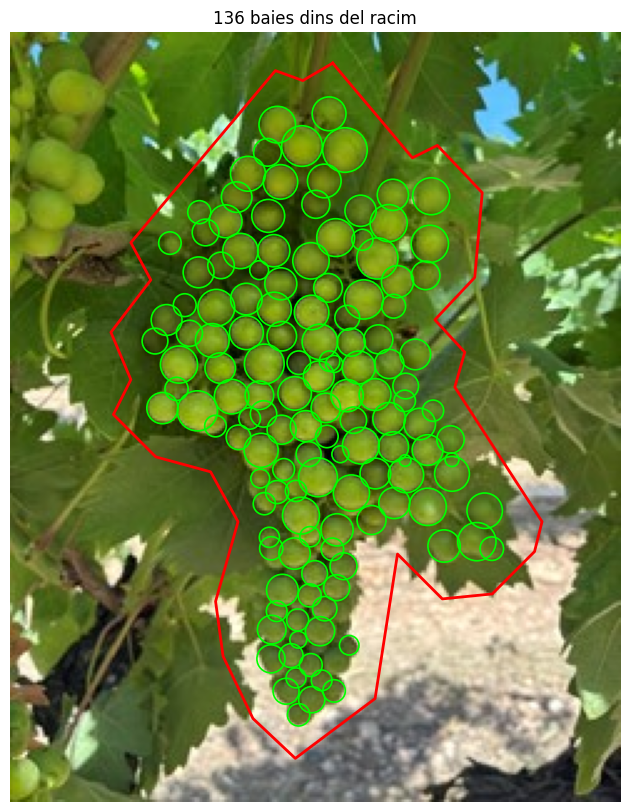

In [21]:
import matplotlib.pyplot as plt
im0 = images_out[0]; img = Image.open(im0['nombre']).convert('RGB')
fig, ax = plt.subplots(figsize=(8, 10)); ax.imshow(img)
if im0['racimo']:
    xs = [p[0] for p in im0['racimo']['puntos']] + [im0['racimo']['puntos'][0][0]]
    ys = [p[1] for p in im0['racimo']['puntos']] + [im0['racimo']['puntos'][0][1]]
    ax.plot(xs, ys, 'r-', lw=2)
for b in im0['bayas']:
    ax.add_patch(plt.Circle((b['cx'], b['cy']), b['r'], fill=False, color='lime', lw=1.2))
ax.set_title(f"{len(im0['bayas'])} baies dins del racim"); ax.axis('off'); plt.show()

In [ ]:
# DIAGNÒSTIC: provar prompts i veure quants candidats i quins scores
import torch
img = Image.open(image_paths[0]).convert('RGB')
processor.set_confidence_threshold(0.05)      # baixem el llindar intern per veure candidats

for prompt in ['berry', 'grape', 'grapes', 'grape berry', 'round green fruit', 'fruit', 'ball']:
    with torch.autocast('cuda', dtype=torch.bfloat16):
        st  = processor.set_image(img)
        out = processor.set_text_prompt(state=st, prompt=prompt)
    sc  = to_np(out['scores']).reshape(-1)
    top = ', '.join(f'{s:.2f}' for s in sorted(sc, reverse=True)[:5])
    print(f"{prompt:18s} -> {len(out['masks']):3d} màscares | millors scores: [{top}]")

In [ ]:
# 6) Descarregar el projecte generat
from google.colab import files
files.download('modelvinya_sam3_proyecto.json')

## Com fer-ho servir a l'anotador
1. Obre l'anotador: **https://planessoria-ui.github.io/ModelVinya/**
2. **📦 Abrir proyecto** → tria `modelvinya_sam3_proyecto.json`.
3. Veuràs les baies **pre-marcades amb cercles**. Revisa i corregeix: mou / redimensiona, esborra falsos positius (Supr) i afegeix els que falten (⭕).
4. **Defineix l'escala** (📏) sobre la referència real per tenir els diàmetres en mm.
5. Omple la fitxa i la veritat de camp, i exporta **CSV / YOLO** com sempre.

### Si la detecció no és bona
- **Racims densos:** prova `PROMPT = 'grape'` o `'round green berry'`, o baixa `AREA_MAX_FRAC`.
- **Massa falsos positius:** puja `SCORE_MIN`.
- **Es perden baies petites:** baixa `AREA_MIN_FRAC`.
- SAM 3 també accepta **punts/caixes** com a prompt visual (exemplars); es pot ampliar el notebook si el text sol no n'hi ha prou.